Дана таблица значений некоторой функциональной зависимости, полученной из n = 6 опытов

    Методом наименьших квадратов по данной табличной зависимости найти аппроксимирующую функцию в виде:

1.1) линейной функции y = a x + b ;

1.2) степенной функции y = β ⋅ x a ;

1.3) показательной функции y = β ⋅ e a x ;

1.4) квадратичной функции y = a x 2 + b x + c .

    Построить в плоскости x O y графики полученных функций и нанести экспериментальные точки.

    Сравнить полученные результаты.

Промежуточные вычисления вести с точностью до 0,0001.

Значения параметров a , b , c округлить до 0,01.

| x  | 2   | 6   | 10  | 14   | 18   | 22   |
|----|-----|-----|-----|------|------|------|
| y  | 3,1 | 6,7 | 9,5 | 11,9 | 14,0 | 15,5 |

In [3]:
import numpy as np

x = np.array([2, 6, 10, 14, 18, 22], dtype=float)
y = np.array([3.1, 6.7, 9.5, 11.9, 14.0, 15.5])
n = x.shape[0]

In [14]:
#Common evaluation, approximations for different fucntions lead to it

X = np.column_stack((np.ones_like(x), x))

A = np.linalg.inv(X.T @ X) @ X.T @ y
A = A[::-1].round(2)
A

array([0.62, 2.72])

In [ ]:
#1.1 linear function

def linear_fit(x, y):
    n = len(x)
    a = (n*np.sum(x*y) - np.sum(x)*np.sum(y)) / (n*np.sum(x**2) - np.sum(x)**2)
    b = (np.sum(y) - a*np.sum(x)) / n
    return np.array([a, b])


coefs_linear = linear_fit(x, y).round(2)
coefs_linear

array([0.62, 2.72])

In [ ]:
#1.2 power function

X_power, y_power = np.log(x), np.log(y)
a_power, b_power = linear_fit(X_power, y_power)
coefs_power = np.array([a_power, np.exp(b_power)]).round(2)
coefs_power

array([0.68, 1.97])

In [ ]:
#1.3 exponential function

X_exp, y_exp = x, np.log(y)
a_exp, b_exp = linear_fit(X_exp, y_exp)
coefs_exp = np.array([a_exp, np.exp(b_exp)]).round(2)
coefs_exp

array([0.07, 3.64])

In [ ]:
#1.4 square function

Sx, Sx2, Sx3, Sx4 = x.sum(), (x**2).sum(), (x**3).sum(), (x**4).sum()

M = np.array([[Sx4, Sx3, Sx2],
              [Sx3, Sx2, Sx ],
              [Sx2, Sx,  n  ]])
r = np.array([(x**2*y).sum(), (x*y).sum(), y.sum()])

D = np.linalg.det(M)

def cramer(k):
    Mk = M.copy()
    Mk[:, k] = r
    return np.linalg.det(Mk) / D

coefs_square = np.array([cramer(0), cramer(1), cramer(2)]).round(2)
coefs_square

array([-0.01,  0.97,  1.27])

#### Построить в плоскости x O y графики полученных функций и нанести экспериментальные точки.

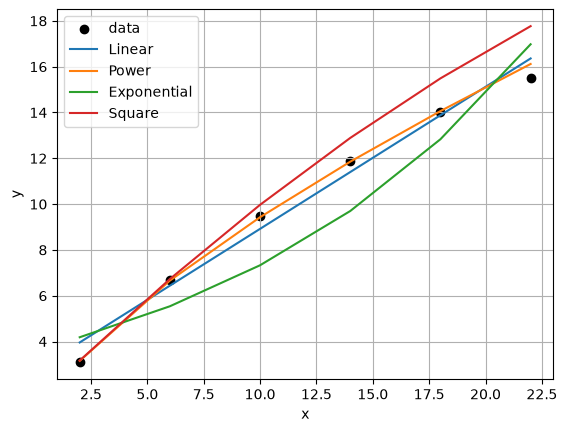

In [38]:
import matplotlib.pyplot as plt

a1, b1 = coefs_linear
a2, b2 = coefs_power
a3, b3 = coefs_exp
a4, b4, c4 = coefs_square

f = {
    'Linear':      lambda t: a1*t + b1,
    'Power':     lambda t: b2 * t**a2,
    'Exponential': lambda t: b3 * np.exp(a3*t),
    'Square':  lambda t: a4*t**2 + b4*t + c4,
}

t = np.linspace(x.min(), x.max(), 300)
plt.scatter(x, y, c="black", label="data")
for name, fn in f.items():
    plt.plot(x, fn(x), label=name)
plt.xlabel('x'); plt.ylabel('y'); plt.grid(True); plt.legend(); plt.show()

In [41]:
for name, fn in f.items():
    resid = y - fn(x)
    S = np.sum(resid**2)
    print(f"{name:14s} S = {S:.4f}")

Linear         S = 2.1476
Power          S = 0.3977
Exponential    S = 15.6328
Square         S = 8.5798


### В данной задаче лучшей аппроксимирующей функцией является степенная: y = 1.97*x^{0.68}
